In [50]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
FNO-3D Inference & Evaluation Pipeline
Clean, modular, and publication-ready.
"""

# --------------------------------------------------------------------------- #
# Standard Library
# --------------------------------------------------------------------------- #
import os
import gc
import time
import argparse
from typing import Tuple, List, Optional

# --------------------------------------------------------------------------- #
# Third-Party
# --------------------------------------------------------------------------- #
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, Subset, DistributedSampler
)
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm
import pandas as pd

# --------------------------------------------------------------------------- #
# Project Paths
# --------------------------------------------------------------------------- #
import sys
sys.path.extend(["../../", "../", "./"])

# --------------------------------------------------------------------------- #
# Custom Modules (Consolidated & Deduplicated)
# --------------------------------------------------------------------------- #

# --- Utilities ---
from lib.util import (
    UnitGaussianNormalizer,
    MHPI,
    run_nvidia_smi,
    split_dataset,
    prepare_data_loaders_low_rank,
)

from lib.utilities3 import (
    load_and_normalize_datasets,
    ensure_directory,
    count_parameters,
    upscale_tensor,
    calculate_errors,
    calculate_relative_errors,
    check_if_from_ddp,
    adjust_state_dict,
    plot_log_loss,
    NonLocalMeansSmoothing,
)

from lib.utiltools import (
    loss_live_plot,
    GaussianRandomFieldGenerator,
    generate_batch_parameters,
    AutomaticWeightedLoss,
)

# --- Jacobian & Derivatives ---
from lib.DerivativeComputer import batchJacobian_AD_Dist
from lib.batchJacobian import batchJacobian_PDE
from lib.low_rank_jacobian import *  

# --- Helper ---
from lib.hellper import *  
# --- Models ---
from models.FNO_3d_t_dist_DDP import FNO3d


In [51]:
def refine_grid_differentiable(field, N):
    """
    Differentiable grid refinement using repeat operations.
    Gradients flow back to the original grid points.
    """
    # [nb, nx, ny] -> [nb, nx, ny, N, N]
    expanded = field.unsqueeze(-1).unsqueeze(-1).repeat(1, 1, 1, N, N)
    
    # [nb, nx, ny, N, N] -> [nb, nx, N, ny, N] -> [nb, N*nx, N*ny]
    refined = expanded.permute(0, 1, 3, 2, 4).contiguous()
    refined = refined.view(field.size(0), N*field.size(1), N*field.size(2))
    
    return refined


# Loading trained model

In [52]:
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}\n')

P_res = 16

# Constants
S = 64
jump_t = 2
train_size = 200

jump_timestep = 2

if jump_timestep == 2:
    total_steps = 30
else:
    total_steps = 60

T_in = 5
T_out = total_steps - T_in


eval_size = 150
enable_ig_loss = 'Enable'  # or 'Enable'    'Disable'

PATH = '../expriments/NSE_SA_multi_res/'


# Load loss file and plot
loss_file_path = PATH + f'loss_epoch/losses_data_NSE_SA_multi_res_IG_' + enable_ig_loss + f'_S_64_Tin_{T_in}_Tout_{T_out}_Samp_omega0_P_res_{P_res}_FNO_DDP_{train_size}.xlsx'
plot_log_loss(loss_file_path, 'Mode', plot_ig_loss=False)

checkpoint_path = PATH + f'saved_models/saved_model_NSE_SA_multi_res_IG_' + enable_ig_loss + f'_S_64_Tin_{T_in}_Tout_{T_out}_Samp_omega0_P_res_{P_res}_FNO_DDP_{train_size}.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)


Device: cuda:0



# Loading dataset

In [55]:
PATH_dataset = f'/storage/group/cxs1024/default/mehdi/datasets/NSE_seq_multi_res_inputs/dataset/navier_stokes_dataset_{P_res}.pt'

full_dataset = torch.load(PATH_dataset, weights_only=False, map_location=device)    
total_size = len(full_dataset)
test_size = total_size - (train_size + eval_size)

# 3. Perform the random split, passing the configured generator
_, _, test_dataset = random_split(
    full_dataset,
    [train_size, eval_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Pass the generator here
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
)

# Define FNO model

In [56]:
# %%
is_DDP = check_if_from_ddp(checkpoint)

if is_DDP:
    model = FNO3d(T_in= checkpoint['T_in'], T_out=checkpoint['T_out'], modes_x=checkpoint['mode1'], modes_y=checkpoint['mode2'], modes_t=checkpoint['mode3'], width=checkpoint['width_FNO'])
    adjusted_state_dict = adjust_state_dict(checkpoint['model_state_dict'], model)
    model.load_state_dict(adjusted_state_dict)


# Forward run the trained model for evaluation

In [57]:
# =============================================
#  INFERENCE PHASE (FULLY FIXED)
# =============================================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# CRITICAL: Move model to GPU
model = model.to(device)
model.eval()

total_samples = 0

W0_full_list       = []
sol_true_full_list = []
sol_pred_full_list = []

t_start = time.time()

with torch.no_grad():
    for batch_data in tqdm(test_loader, desc="Inference", leave=False):
        # Move batch to GPU
        batch_data = [item.to(device, non_blocking=True) for item in batch_data]
        _, W0_batch, sol_batch, _, _ = batch_data

        batch_size = W0_batch.shape[0]
        total_samples += batch_size

        # True solution
        sol_true = sol_batch[..., ::jump_timestep][..., T_in:]
        sol_in = sol_batch[..., ::jump_timestep][..., :T_in]

        # Upsample low-res input (W0_batch is already on GPU)
        target_size = sol_batch.shape[1]
        w0 = refine_grid_differentiable(W0_batch, int(target_size / W0_batch.shape[1]))

        # w0 is on same device as W0_batch → already on GPU
        # No need to .to(device) again

        # Forward
        sol_Pred = model(sol_in, w0)  # Both w0 and model on GPU

        # Store on CPU
        W0_full_list.append(W0_batch.cpu())
        sol_true_full_list.append(sol_true.cpu())
        sol_pred_full_list.append(sol_Pred.cpu())

        # Clean
        del w0, sol_Pred, sol_true
        torch.cuda.empty_cache()

# Concatenate
W0_full       = torch.cat(W0_full_list, dim=0)
sol_true_full = torch.cat(sol_true_full_list, dim=0)
sol_pred_full = torch.cat(sol_pred_full_list, dim=0)

t_end = time.time()
print(f'\nInference done: {total_samples} samples in {t_end - t_start:.2f}s')

Inference:   0%|          | 0/82 [00:00<?, ?it/s]


Inference done: 650 samples in 3.05s


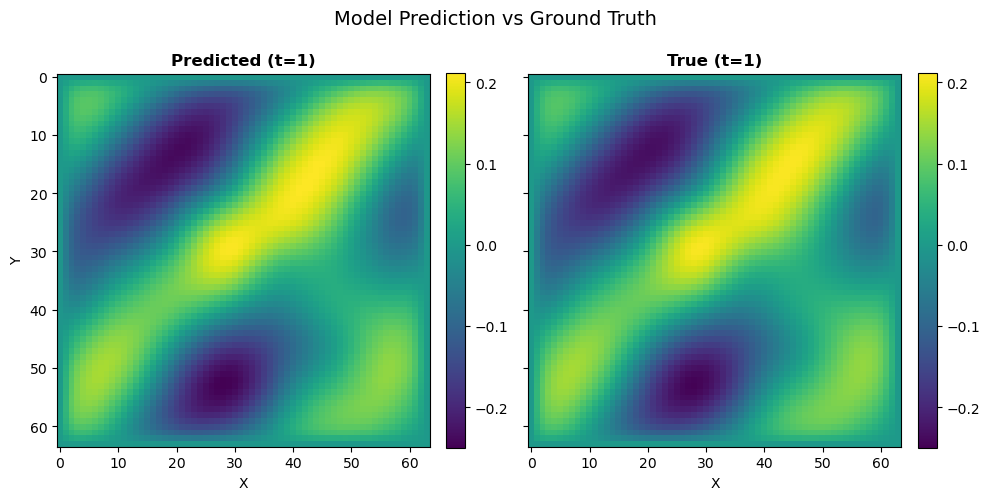

In [58]:
import matplotlib.pyplot as plt
import numpy as np
t_idx = 5
# -------------------------------------------------
#  SIDE-BY-SIDE: Predicted vs True (t=1)
# -------------------------------------------------
pred_slice = sol_pred_full[0, :, :, t_idx].cpu().numpy()
true_slice = sol_true_full[0, :, :, t_idx].cpu().numpy()

vmin = min(pred_slice.min(), true_slice.min())
vmax = max(pred_slice.max(), true_slice.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# Predicted
im0 = axes[0].imshow(pred_slice, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Predicted (t=1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# True
im1 = axes[1].imshow(true_slice, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('True (t=1)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle('Model Prediction vs Ground Truth', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

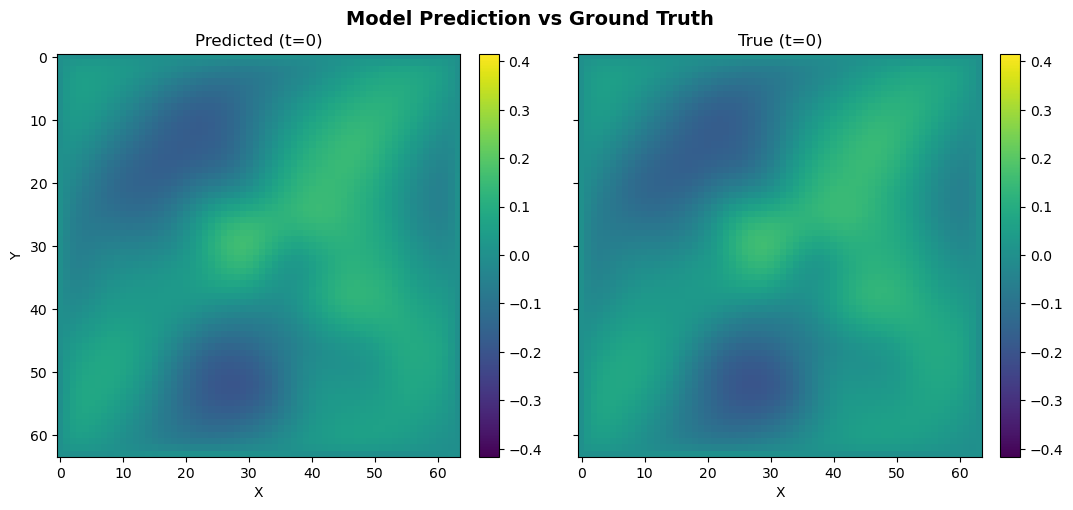

In [47]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

# -------------------------------------------------
#  ANIMATION: Predicted vs True over time
# -------------------------------------------------
site_idx = 0  # Which site to visualize
pred_full = sol_pred_full[site_idx].cpu().numpy()   # [X, Y, T]
true_full = sol_true_full[site_idx].cpu().numpy()   # [X, Y, T]

# Global min/max for consistent color scale
vmin = min(pred_full.min(), true_full.min())
vmax = max(pred_full.max(), true_full.max())

# Setup figure
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
fig.suptitle('Model Prediction vs Ground Truth', fontsize=14, fontweight='bold', y=0.98)

# Initial images
im_pred = axes[0].imshow(pred_full[..., 0], cmap='viridis', vmin=vmin, vmax=vmax, animated=True)
im_true = axes[1].imshow(true_full[..., 0], cmap='viridis', vmin=vmin, vmax=vmax, animated=True)

# Colorbars
cb_pred = fig.colorbar(im_pred, ax=axes[0], fraction=0.046, pad=0.04)
cb_true = fig.colorbar(im_true, ax=axes[1], fraction=0.046, pad=0.04)

# Titles
title_pred = axes[0].set_title(f'Predicted (t=0)', fontsize=12)
title_true = axes[1].set_title(f'True (t=0)', fontsize=12)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[1].set_xlabel('X')

plt.tight_layout()

# -------------------------------------------------
#  Animation update function
# -------------------------------------------------
def update(frame):
    im_pred.set_array(pred_full[..., frame])
    im_true.set_array(true_full[..., frame])
    title_pred.set_text(f'Predicted (t={frame})')
    title_true.set_text(f'True (t={frame})')
    return im_pred, im_true, title_pred, title_true

# Create animation
ani = animation.FuncAnimation(
    fig, update, frames=pred_full.shape[-1],
    interval=150, blit=False, repeat=True
)

# Display in Jupyter
HTML(ani.to_jshtml())

In [59]:
import os
import torch
import numpy as np

# -------------------------------------------------
#  ERROR COMPUTATION USING YOUR FUNCTIONS (TENSOR INPUT)
# -------------------------------------------------
save_path = "../errors"
os.makedirs(save_path, exist_ok=True)

Mode = f'{P_res}'
print(f"\n=== Results for Mode: {Mode} ===\n")

# -------------------------------------------------
#  Use full prediction tensors (on GPU or CPU)
# -------------------------------------------------
u_pred = sol_pred_full  # [B, X, Y, T_out] → torch.Tensor
u_true = sol_true_full  # [B, X, Y, T_out] → torch.Tensor

# Move to CPU (your functions likely use .cpu())
u_pred = u_pred.cpu()
u_true = u_true.cpu()

# Flatten to 1D
u_pred_flat = u_pred.flatten()
u_true_flat = u_true.flatten()

# -------------------------------------------------
#  Remove NaNs (critical!)
# -------------------------------------------------
mask = torch.isfinite(u_true_flat) & torch.isfinite(u_pred_flat)
u_true_clean = u_true_flat[mask]
u_pred_clean = u_pred_flat[mask]

if u_true_clean.numel() == 0:
    raise ValueError("No valid (non-NaN) data points after masking!")

# -------------------------------------------------
#  CALL YOUR ERROR FUNCTIONS (they expect torch.Tensor)
# -------------------------------------------------
l2_error_state, r2_score_state, max_abs_error_state = calculate_errors(u_pred_clean, u_true_clean)
l1_relative_error_state, l2_relative_error_state = calculate_relative_errors(u_pred_clean, u_true_clean)

# -------------------------------------------------
#  PRINT RESULTS
# -------------------------------------------------
print(f"R² Score:               {r2_score_state:.6f}")
print(f"RMSE (L2 mean error):   {l2_error_state:.2e}")
print(f"L1 Relative Error:      {l1_relative_error_state:.3%}")
print(f"L2 Relative Error:      {l2_relative_error_state:.3%}")
print(f"Max Absolute Error:     {max_abs_error_state:.3f}\n")



=== Results for Mode: 16 ===

R² Score:               0.999189
RMSE (L2 mean error):   3.64e-03
L1 Relative Error:      2.988%
L2 Relative Error:      2.848%
Max Absolute Error:     0.044

